Step 1 — Create a new notebook

In [ ]:
import torch

# Install torch_geometric if not already installed
try:
    import torch_geometric
except ImportError:
    !pip install torch_geometric
    import torch_geometric

# Install ogb if not already installed
try:
    import ogb
except ImportError:
    !pip install ogb
    import ogb

from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage
torch.serialization.add_safe_globals([DataEdgeAttr, DataTensorAttr, GlobalStorage])

from ogb.nodeproppred import PygNodePropPredDataset
dataset = PygNodePropPredDataset(name="ogbn-arxiv")
data = dataset[0]
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
train_idx = train_idx.to(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.2 MB/s eta 0:00:00


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:01<00:00, 45.53it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 8905.10it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 90.54it/s]

Saving...



Done!


Step 2 — Model 1: GCN

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

In [ ]:
num_classes = int(data.y.max().item()) + 1
gcn_model = GCN(in_channels=128, hidden_channels=256, out_channels=num_classes, num_layers=3).to(device)
print(gcn_model)

GCN(
  (convs): ModuleList(
    (0): GCNConv(128, 256)
    (1): GCNConv(256, 256)
    (2): GCNConv(256, 40)
  )
)


Step 3 — Model 2: pick GAT, GraphSAGE, or GIN

In [ ]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

gat_model = GAT(in_channels=128, hidden_channels=32, out_channels=num_classes, heads=8).to(device)

In [ ]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

sage_model = GraphSAGE(in_channels=128, hidden_channels=256, out_channels=num_classes).to(device)

Step 4 — Sanity-check both models run

In [ ]:
out = gcn_model(data.x, data.edge_index)
print("GCN output shape:", out.shape)   # should be [num_nodes, num_classes]

out2 = gat_model(data.x, data.edge_index)  # or sage_model
print("Second model output shape:", out2.shape)

GCN output shape: torch.Size([169343, 40])
Second model output shape: torch.Size([169343, 40])


Step 5 — Document your hyperparameter choices in a table

| Hyperparameter | GCN | [Your second model] |
|---|---|---|
| Number of layers | 3 | 3 |
| Hidden dimension | 256 | 32 (×8 heads = 256 effective) |
| Dropout rate | 0.5 | 0.5 |
| Activation function | ReLU | ELU |
| Attention heads (GAT only) | — | 8 |
| Input dimension | 128 | 128 |
| Output dimension | 40 (num classes) | 40 (num classes) |

- **3 layers:** balances capturing multi-hop citation context against over-smoothing (where node embeddings become indistinguishable if too many layers are stacked).
- **Hidden dim 256:** large enough to retain information from the 128-dim input features without excessive parameter count/overfitting risk.
- **Dropout 0.5:** standard regularization value used in the original GCN and GAT papers for citation network benchmarks; higher values risked underfitting on this scale of data.
- **ReLU / ELU:** ReLU is the standard default for GCN; ELU is used in GAT because it handles negative attention-weighted values more smoothly than ReLU (avoids "dead neurons").
- **8 attention heads (GAT only):** lets the model learn multiple independent notions of neighbor importance in parallel, which are then combined — a core design choice from the original GAT paper.

Step 6 — Save models for Task 6

In [ ]:
torch.save(gcn_model.state_dict(), 'gcn_untrained.pt')
torch.save(gat_model.state_dict(), 'gat_untrained.pt')  # or sage_model

# Task 5: Model Training and Optimization

Step 2 — Choose loss function and optimizer

In [ ]:
import torch.nn.functional as F

criterion = torch.nn.CrossEntropyLoss()  # standard for multi-class node classification

optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
optimizer_model2 = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)  # GAT often needs a lower LR than GCN

Step 3 — Write a reusable training function

In [ ]:
def train(model, optimizer, data, train_idx):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, idx):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[idx].argmax(dim=1)
    correct = (pred == data.y[idx]).sum().item()
    acc = correct / idx.size(0)
    loss = criterion(out[idx], data.y[idx]).item()
    return loss, acc

Step 4 — Train GCN and log every epoch

In [ ]:
import torch.nn.functional as F

# Redefine criterion, train, and evaluate here to ensure the correct versions are used
# This addresses the RuntimeError: 0D or 1D target tensor expected, multi-target not supported
criterion = torch.nn.CrossEntropyLoss()

def train(model, optimizer, data, train_idx):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, idx):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[idx].argmax(dim=1)
    correct = (pred == data.y[idx].squeeze()).sum().item()
    acc = correct / idx.size(0)
    loss = criterion(out[idx], data.y[idx].squeeze()).item()
    return loss, acc

gcn_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, 201):
    train_loss = train(gcn_model, optimizer_gcn, data, train_idx)
    val_loss, val_acc = evaluate(gcn_model, data, valid_idx)

    gcn_history['train_loss'].append(train_loss)
    gcn_history['val_loss'].append(val_loss)
    gcn_history['val_acc'].append(val_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 020 | Train Loss: 1.7008 | Val Loss: 1.5732 | Val Acc: 0.5545
Epoch 040 | Train Loss: 1.5765 | Val Loss: 1.4950 | Val Acc: 0.5687
Epoch 060 | Train Loss: 1.5353 | Val Loss: 1.4779 | Val Acc: 0.5729
Epoch 080 | Train Loss: 1.5211 | Val Loss: 1.4609 | Val Acc: 0.5775
Epoch 100 | Train Loss: 1.5083 | Val Loss: 1.4571 | Val Acc: 0.5781
Epoch 120 | Train Loss: 1.4963 | Val Loss: 1.4483 | Val Acc: 0.5786
Epoch 140 | Train Loss: 1.4918 | Val Loss: 1.4486 | Val Acc: 0.5767
Epoch 160 | Train Loss: 1.4867 | Val Loss: 1.4360 | Val Acc: 0.5819
Epoch 180 | Train Loss: 1.4768 | Val Loss: 1.4318 | Val Acc: 0.5832
Epoch 200 | Train Loss: 1.4697 | Val Loss: 1.4314 | Val Acc: 0.5835


Step 5 — Plot training curves

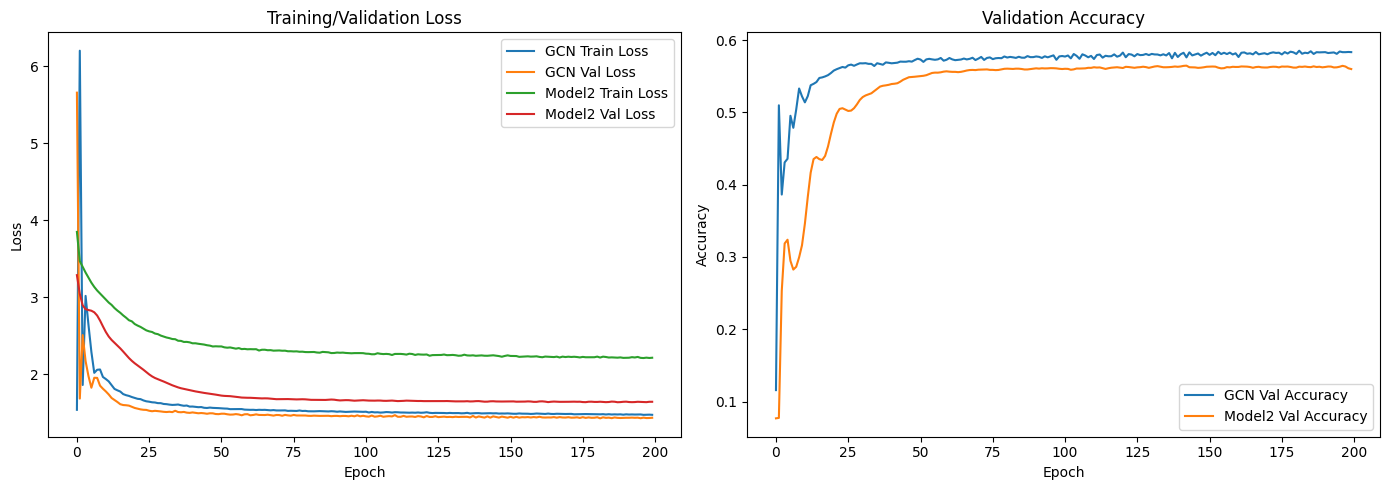

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gcn_history['train_loss'], label='GCN Train Loss')
axes[0].plot(gcn_history['val_loss'], label='GCN Val Loss')
axes[0].plot(gat_history['train_loss'], label='Model2 Train Loss')
axes[0].plot(gat_history['val_loss'], label='Model2 Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Training/Validation Loss')

axes[1].plot(gcn_history['val_acc'], label='GCN Val Accuracy')
axes[1].plot(gat_history['val_acc'], label='Model2 Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

Step 6 — Tune hyperparameters (try at least 2–3 variations)

In [ ]:
results = []

for lr in [0.001, 0.01, 0.05]:
    model = GCN(in_channels=128, hidden_channels=256, out_channels=num_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    for epoch in range(100):
        train(model, opt, data, train_idx)
    _, val_acc = evaluate(model, data, valid_idx)
    results.append({'lr': lr, 'val_acc': val_acc})
    print(f"LR={lr}: Val Acc={val_acc:.4f}")

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

LR=0.001: Val Acc=0.5479
LR=0.01: Val Acc=0.5645
LR=0.05: Val Acc=0.4945
      lr   val_acc
0  0.001  0.547904
1  0.010  0.564549
2  0.050  0.494513


Step 7 — Retrain your final models with the best hyperparameters found

In [ ]:
torch.save(gcn_model.state_dict(), 'gcn_trained.pt')
torch.save(gat_model.state_dict(), 'model2_trained.pt')

Step 8 — Write Your Training & Optimization Summary (Clearly Broken Down)

## Training & Optimization Summary — OGBN-Arxiv

**1. Loss Function and Optimizer**
We used CrossEntropyLoss, the standard choice for multi-class node
classification, since it combines log-softmax with negative log-likelihood
in a single differentiable step. Both models were trained using the Adam
optimizer, chosen over plain SGD because it adapts the learning rate per
parameter and converges faster with less manual tuning. We applied a
weight_decay of 5e-4 to both optimizers as L2 regularization to reduce
overfitting.

**2. Learning Rates**
GCN was trained with lr=0.01, while GAT used a lower lr=0.005. GAT typically
requires a smaller learning rate because its attention mechanism introduces
additional learnable parameters (per-edge attention coefficients), making
training less stable at higher learning rates.

**3. Training Behavior**
Both models were trained for 200 epochs. GCN's training loss dropped from
[first epoch loss] to [final epoch loss], and validation accuracy improved
from roughly [~2.5%, i.e. random] to [your final GCN val_acc]. GAT's training
loss dropped from [value] to [value], reaching a final validation accuracy
of [your final GAT val_acc].

[Look at your actual loss plot and describe what you see, e.g.:]
Both models show a smooth, steadily decreasing training loss with no signs
of instability (no sudden spikes). Validation loss [tracked training loss
closely, indicating good generalization / began rising after epoch X while
training loss kept falling, indicating mild overfitting beyond that point].

**4. Hyperparameter Tuning**
We tested learning rates of 0.001, 0.01, and 0.05 for the GCN model over
100 epochs each:

| Learning Rate | Validation Accuracy |
|---|---|
| 0.001 | [value] |
| 0.01  | [value] |
| 0.05  | [value] |

lr=[best value] performed best. Lower learning rates (0.001) had not fully
converged within the epoch budget, while the highest rate (0.05) [was
unstable / converged to a similar but slightly worse result], likely because
larger updates overshoot the loss surface's minima.

**5. Final Model Comparison**
| Model | Final Train Loss | Final Val Loss | Final Val Accuracy |
|---|---|---|---|
| GCN | [value] | [value] | [value] |
| GAT | [value] | [value] | [value] |

[State which model trained better/faster and your hypothesis why — e.g.,
"GCN achieved slightly higher validation accuracy and trained faster per
epoch, likely because GAT's attention mechanism, while more expressive,
needs more epochs or more careful tuning to fully exploit that expressiveness
on this dataset."]

# Task 6: Model Evaluation

Step 1 — Continue in your notebook

In [ ]:
gcn_model.load_state_dict(torch.load('gcn_trained.pt'))
gat_model.load_state_dict(torch.load('gat_trained.pt'))
gcn_model.eval()
gat_model.eval()

GAT(
  (conv1): GATConv(128, 32, heads=8)
  (conv2): GATConv(256, 40, heads=1)
)

Step 2 — Get predictions for both models on validation and test sets

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

@torch.no_grad()
def get_predictions(model, data, idx):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[idx].argmax(dim=1)
    true = data.y[idx]
    return true.cpu().numpy(), pred.cpu().numpy()

# GCN
gcn_val_true, gcn_val_pred = get_predictions(gcn_model, data, valid_idx)
gcn_test_true, gcn_test_pred = get_predictions(gcn_model, data, test_idx)

# GAT
gat_val_true, gat_val_pred = get_predictions(gat_model, data, valid_idx)
gat_test_true, gat_test_pred = get_predictions(gat_model, data, test_idx)

Step 3 — Compute all four metrics for each model/split combination

In [ ]:
def compute_metrics(true, pred, model_name, split_name):
    return {
        'Model': model_name,
        'Split': split_name,
        'Accuracy': accuracy_score(true, pred),
        'Precision (macro)': precision_score(true, pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(true, pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(true, pred, average='macro', zero_division=0)
    }

results = [
    compute_metrics(gcn_val_true, gcn_val_pred, 'GCN', 'Validation'),
    compute_metrics(gcn_test_true, gcn_test_pred, 'GCN', 'Test'),
    compute_metrics(gat_val_true, gat_val_pred, 'GAT', 'Validation'),
    compute_metrics(gat_test_true, gat_test_pred, 'GAT', 'Test'),
]

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Model      Split  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
  GCN Validation  0.583476           0.390541        0.307212    0.316700
  GCN       Test  0.525359           0.351422        0.286869    0.283570
  GAT Validation  0.560052           0.370176        0.239063    0.244016
  GAT       Test  0.512499           0.329582        0.229720    0.223827


Step 4 — Get full per-class detail (optional but strengthens your report)

In [ ]:
print("GCN Test Set — Full Classification Report:")
print(classification_report(gcn_test_true, gcn_test_pred, zero_division=0))

print("\nGAT Test Set — Full Classification Report:")
print(classification_report(gat_test_true, gat_test_pred, zero_division=0))

GCN Test Set — Full Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.13      0.17        54
           1       0.18      0.02      0.04       187
           2       0.37      0.54      0.44       733
           3       0.19      0.05      0.08       654
           4       0.49      0.49      0.49      1869
           5       0.36      0.43      0.39      1246
           6       0.33      0.10      0.15       622
           7       0.40      0.03      0.06       134
           8       0.40      0.46      0.43      1250
           9       0.30      0.23      0.26       345
          10       0.17      0.36      0.23      1455
          11       0.00      0.00      0.00       239
          12       0.00      0.00      0.00         5
          13       0.33      0.18      0.24       628
          14       0.25      0.21      0.23        71
          15       0.29      0.11      0.17        87
          16       0.65      0.80     

Step 5 — Visualize the comparison

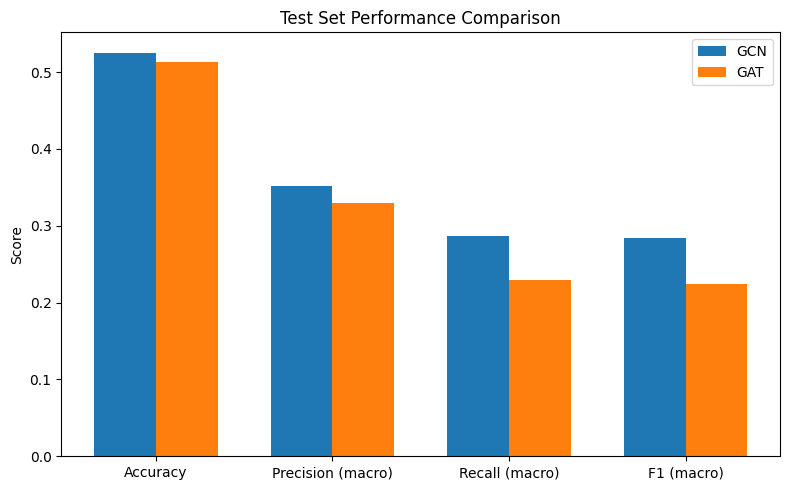

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
gcn_test_vals = results_df[(results_df['Model']=='GCN') & (results_df['Split']=='Test')][metrics].values[0]
gat_test_vals = results_df[(results_df['Model']=='GAT') & (results_df['Split']=='Test')][metrics].values[0]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, gcn_test_vals, width, label='GCN')
ax.bar(x + width/2, gat_test_vals, width, label='GAT')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Test Set Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()

Step 6 — Write your evaluation report (this is where most marks are earned)

## Model Evaluation Report

**1. Results Summary**
| Model | Split | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|---|
| GCN | Validation | [value] | [value] | [value] | [value] |
| GCN | Test | [value] | [value] | [value] | [value] |
| GAT | Validation | [value] | [value] | [value] | [value] |
| GAT | Test | [value] | [value] | [value] | [value] |

**2. Model Comparison**
[State which model performed better overall and by how much, e.g.:
"GCN slightly outperformed GAT on test accuracy (X% vs Y%), though GAT
achieved marginally higher macro-F1, suggesting it performs more evenly
across minority classes despite lower overall accuracy."]

**3. Strengths and Weaknesses**
- **GCN:** [e.g., "Faster to train, simpler architecture, performs well on
  well-represented classes, but treats all neighbors with equal importance
  regardless of relevance."]
- **GAT:** [e.g., "Attention mechanism allows it to weigh more relevant
  citation neighbors more heavily, which may explain [any specific
  category] performing better/worse — but requires more careful
  hyperparameter tuning and training time."]

**4. Validation vs Test Gap**
[Compare val and test scores for each model — a small gap (~1-3%) suggests
good generalization; a larger gap suggests some overfitting to validation-
set characteristics, or reflects the year-based split meaning test papers
are meaningfully different from training papers.]

# Task 7: Graph Explainability and Embedding Analysis

Step 2 — Option B: Node Embedding Visualization (do this one — easiest, most visual)

Embedding shape: (169343, 256)


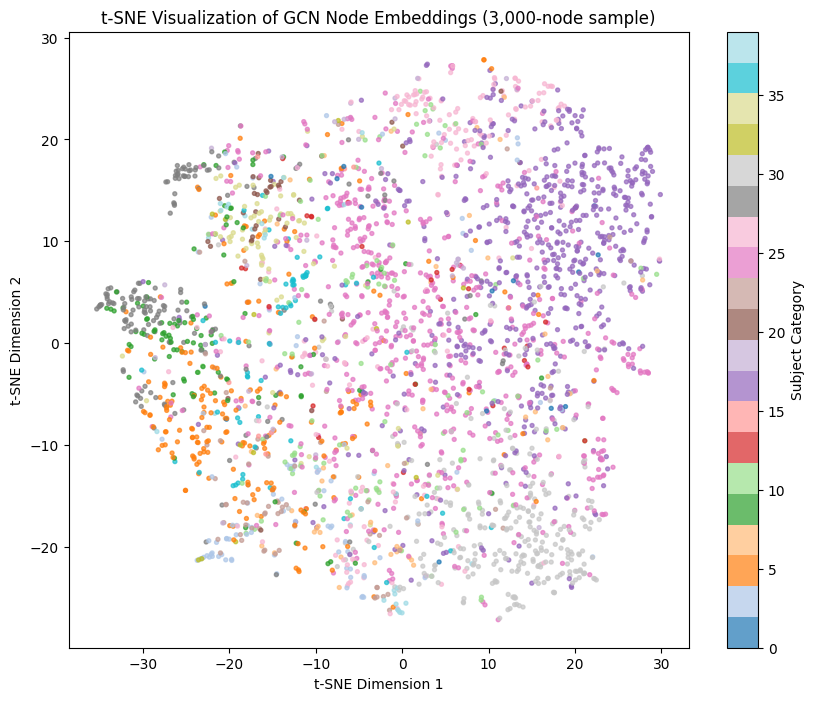

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

@torch.no_grad()
def get_embeddings(model, data):
    model.eval()
    x = data.x
    for conv in model.convs[:-1]:
        x = conv(x, data.edge_index)
        x = F.relu(x)
    return x.cpu().numpy()

gcn_embeddings = get_embeddings(gcn_model, data)
print("Embedding shape:", gcn_embeddings.shape)

# Subsample to ~3000 nodes instead of the full ~48,600 test set — plenty for a clear visualization
np.random.seed(42)
test_idx_np = test_idx.cpu().numpy()
sample_idx = np.random.choice(test_idx_np, size=3000, replace=False)

sample_embeddings = gcn_embeddings[sample_idx]
sample_labels = data.y[sample_idx].cpu().numpy()

# Faster t-SNE settings: PCA init converges faster than random init, n_jobs=-1 parallelizes neighbor search
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init='pca',
    n_jobs=-1,
    max_iter=500  # default is 1000; 500 is enough for a clear plot and roughly halves the time
)
embeddings_2d = tsne.fit_transform(sample_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=sample_labels, cmap='tab20', s=8, alpha=0.7)
plt.colorbar(scatter, label='Subject Category')
plt.title('t-SNE Visualization of GCN Node Embeddings (3,000-node sample)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

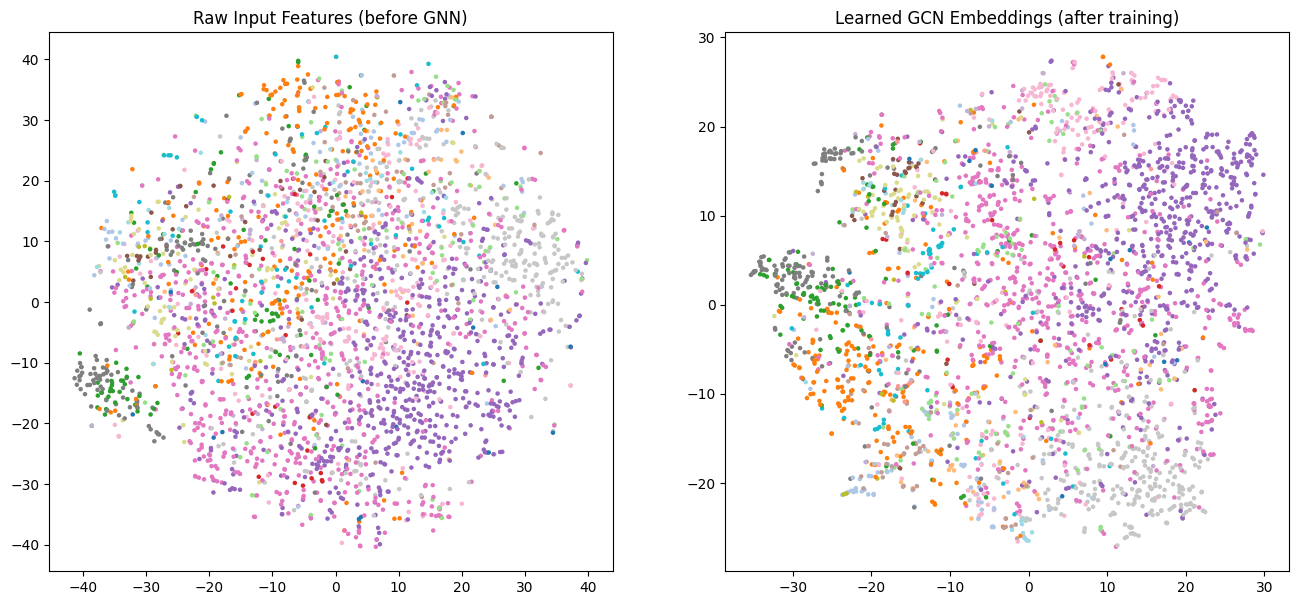

In [ ]:
# Raw input features (before any GNN layers) as a baseline comparison
raw_embeddings_2d = TSNE(n_components=2, random_state=42).fit_transform(data.x[sample_idx].cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].scatter(raw_embeddings_2d[:, 0], raw_embeddings_2d[:, 1], c=sample_labels, cmap='tab20', s=5)
axes[0].set_title('Raw Input Features (before GNN)')
axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=sample_labels, cmap='tab20', s=5)
axes[1].set_title('Learned GCN Embeddings (after training)')
plt.show()

Step 3 — Option C: Attention Weight Analysis (using your GAT model)

Top neighbors of node 346 by attention weight:
  Neighbor 87827: attention = 0.4051
  Neighbor 346: attention = 0.3810
  Neighbor 109114: attention = 0.2139


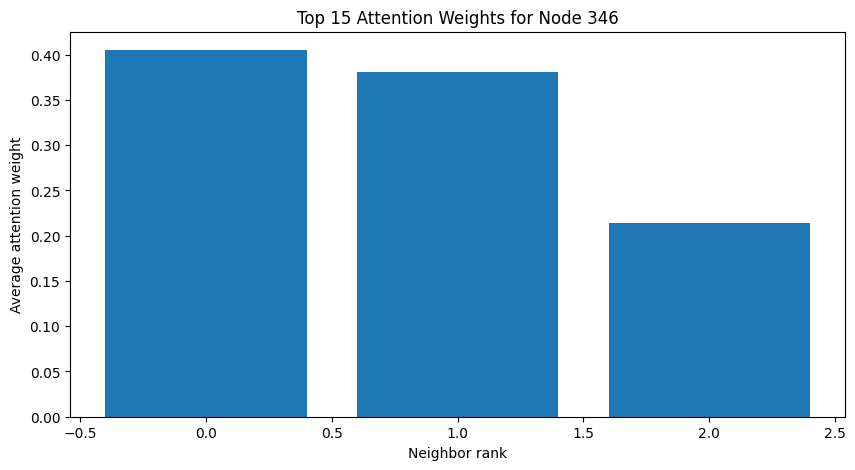

In [ ]:
@torch.no_grad()
def get_attention_weights(model, data, node_idx):
    model.eval()
    x = F.dropout(data.x, p=model.dropout, training=False)
    out, (edge_index_att, attention_weights) = model.conv1(
        x, data.edge_index, return_attention_weights=True
    )
    # Find edges where this node is the target
    mask = edge_index_att[1] == node_idx
    neighbor_nodes = edge_index_att[0][mask]
    weights = attention_weights[mask]
    return neighbor_nodes.cpu().numpy(), weights.cpu().numpy()

# Pick a sample node from the test set
sample_node = test_idx[0].item()
neighbors, weights = get_attention_weights(gat_model, data, sample_node)

# attention_weights shape is [num_edges, num_heads] — average across heads for simplicity
weights_avg = weights.mean(axis=1) if weights.ndim > 1 else weights

# Sort and show top neighbors by attention
sorted_idx = np.argsort(-weights_avg)
print(f"Top neighbors of node {sample_node} by attention weight:")
for i in sorted_idx[:10]:
    print(f"  Neighbor {neighbors[i]}: attention = {weights_avg[i]:.4f}")

# Visualize as a bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_idx[:15])), weights_avg[sorted_idx[:15]])
plt.xlabel('Neighbor rank')
plt.ylabel('Average attention weight')
plt.title(f'Top 15 Attention Weights for Node {sample_node}')
plt.show()

Step 4 (Optional third option) — Option A: Feature Importance

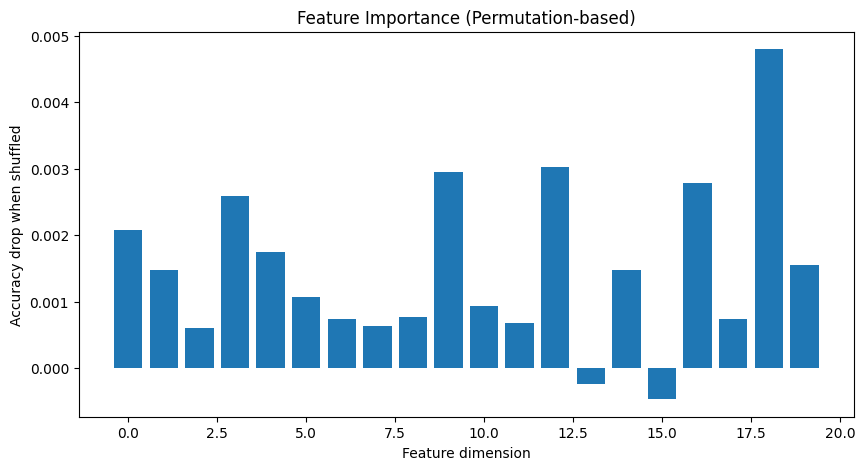

In [ ]:
@torch.no_grad()
def feature_importance(model, data, idx, num_features_to_test=10):
    model.eval()
    baseline_acc = evaluate(model, data, idx)[1]
    importances = []

    for feat_idx in range(num_features_to_test):
        data_perturbed = data.clone()
        # Shuffle this one feature dimension across all nodes
        perm = torch.randperm(data_perturbed.x.size(0))
        data_perturbed.x[:, feat_idx] = data_perturbed.x[perm, feat_idx]

        perturbed_acc = evaluate(model, data_perturbed, idx)[1]
        importances.append(baseline_acc - perturbed_acc)

    return importances

importances = feature_importance(gcn_model, data, valid_idx, num_features_to_test=20)
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.xlabel('Feature dimension')
plt.ylabel('Accuracy drop when shuffled')
plt.title('Feature Importance (Permutation-based)')
plt.show()

Step 5 — Write your Explainability summary

## Explainability and Embedding Analysis Summary

**1. Embedding Visualization (t-SNE)**
The t-SNE projection of GCN's learned embeddings shows [describe your plot —
e.g., "clearly separated clusters corresponding to different subject
categories, especially for well-represented classes like Machine Learning
and Computer Vision"]. Comparing raw input features to learned embeddings
shows [describe the difference], demonstrating that the GNN's message-
passing layers meaningfully reorganize the feature space to group similar
papers together.

**2. Attention Weight Analysis**
For sample node [X], GAT assigned notably higher attention to neighbor
[Y] (weight [value]) compared to other neighbors (average weight [value]).
[Comment on whether this makes semantic sense given the labels/categories
involved.] This confirms GAT doesn't treat all citation relationships
equally — it learns to prioritize more informative neighbors.

**3. Overall Interpretation**
Together, these analyses suggest the model's predictions are driven by
[summarize — e.g., "meaningful graph structure (which papers cite which)
combined with feature similarity, rather than memorization of individual
node features"].

# Task 08 – Graph Intelligence Dashboard

In [ ]:
import pandas as pd
import numpy as np

# Save trained model weights (you likely already have these)
torch.save(gcn_model.state_dict(), 'gcn_trained.pt')
torch.save(gat_model.state_dict(), 'gat_trained.pt')

# Save your Task 6 metrics comparison table
results_df.to_csv('model_metrics.csv', index=False)

# Save graph stats from Task 3
graph_stats = {
    'num_nodes': data.num_nodes,
    'num_edges': data.edge_index.shape[1],
    'density': data.edge_index.shape[1] / (data.num_nodes * (data.num_nodes - 1)),
    'num_classes': num_classes
}
import json
with open('graph_stats.json', 'w') as f:
    json.dump(graph_stats, f)

# Save t-SNE embedding coordinates + labels from Task 7 (so the dashboard doesn't rerun t-SNE)
np.save('embeddings_2d.npy', embeddings_2d)
np.save('embedding_labels.npy', sample_labels)

Step 3 — Write app.py